# Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

sns.set_theme(style="whitegrid")
warnings.filterwarnings('ignore')
print("Libraries imported successfully for Insights & Optimization!")

Libraries imported successfully for Insights & Optimization!


# Load the Model and Raw Data

In [2]:
#Load the original unencoded data for easy human-readable analysis
raw_data_path = '../data/freight_shipping_data.csv'
df_raw = pd.read_csv(raw_data_path)

#Load the trained Regressor and the saved feature columns
model_path = '../models/eta_regressor.pkl'
columns_path = '../models/model_columns.pkl'

regressor = joblib.load(model_path)
model_columns = joblib.load(columns_path)

print("Data and Model loaded successfully.")

Data and Model loaded successfully.


# Feature Importance

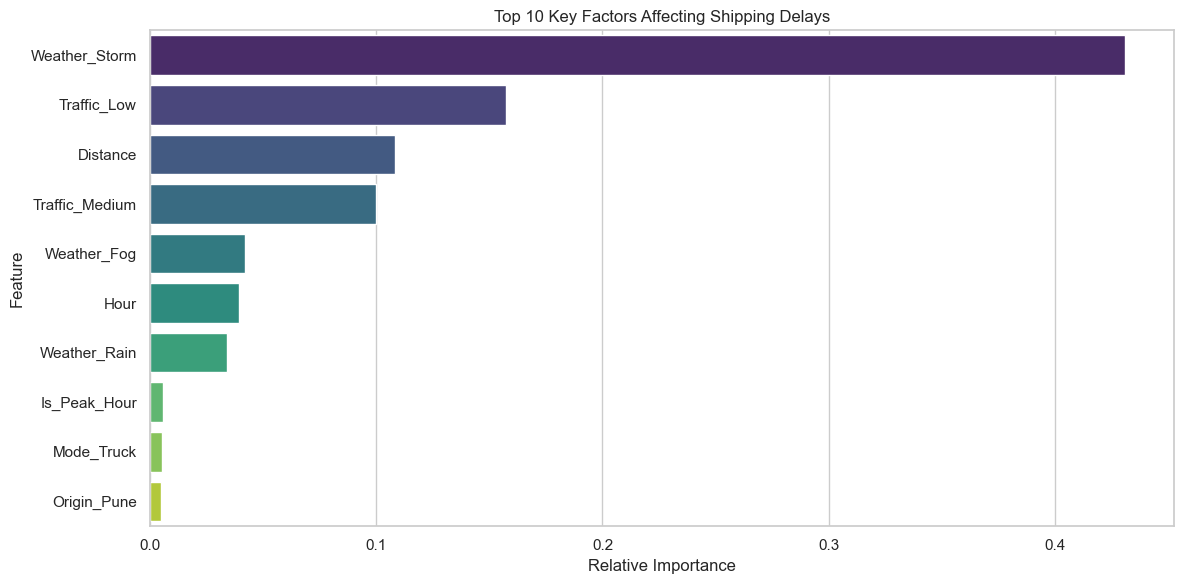

Insight: The features at the top of this chart are the primary drivers of delay in  logistics network.


In [7]:
# Extract feature importances from the Random Forest Regressor
importances = regressor.feature_importances_

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': model_columns,
    'Importance': importances
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')
plt.title('Top 10 Key Factors Affecting Shipping Delays')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("Insight: The features at the top of this chart are the primary drivers of delay in  logistics network.")

# Business Recommendation - Best Transport Mode

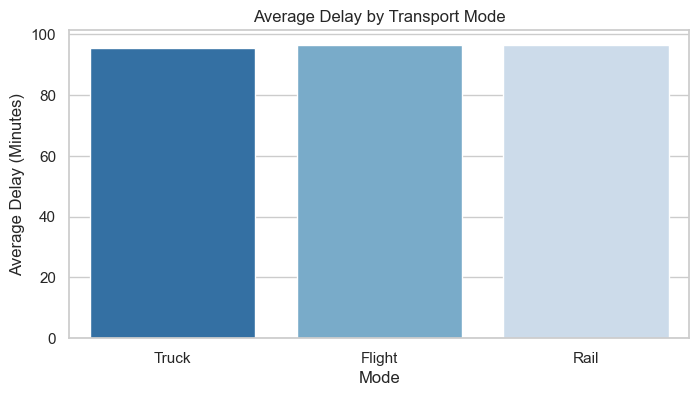

Recommendation: 'Truck' is historically the most reliable transport mode with the lowest average delay.


In [4]:
#Group by Mode to find the average delay
mode_analysis = df_raw.groupby('Mode')['Delay'].mean().reset_index()
mode_analysis = mode_analysis.sort_values(by='Delay')

plt.figure(figsize=(8, 4))
sns.barplot(x='Mode', y='Delay', data=mode_analysis, palette='Blues_r')
plt.title('Average Delay by Transport Mode')
plt.ylabel('Average Delay (Minutes)')
plt.show()

best_mode = mode_analysis.iloc[0]['Mode']
print(f"Recommendation: '{best_mode}' is historically the most reliable transport mode with the lowest average delay.")

# Business Recommendation - Best Departure Time & Weather Impact

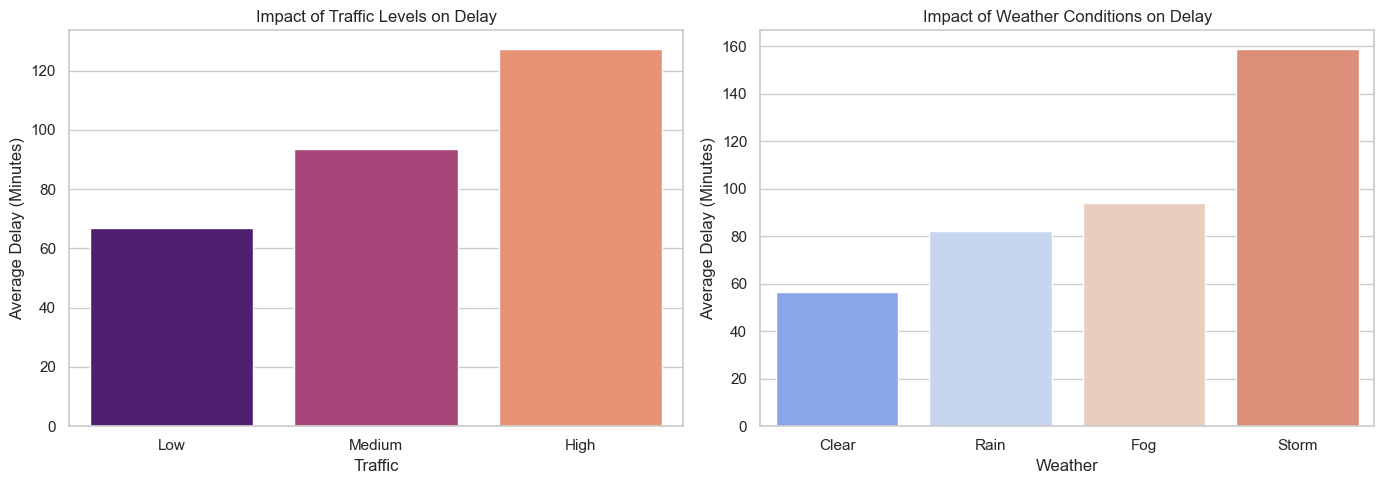

Recommendation Summary for Operations Team:
- Optimal conditions for dispatch: Traffic = 'Low', Weather = 'Clear'.
- Actionable Step: Avoid scheduling high-priority shipments during 'High' traffic or 'Storm' conditions whenever possible.


In [6]:
#Group by Traffic to simulate peak/non-peak impact
traffic_analysis = df_raw.groupby('Traffic')['Delay'].mean().reset_index().sort_values(by='Delay')

#Group by Weather 
weather_analysis = df_raw.groupby('Weather')['Delay'].mean().reset_index().sort_values(by='Delay')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(ax=axes[0], x='Traffic', y='Delay', data=traffic_analysis, palette='magma')
axes[0].set_title('Impact of Traffic Levels on Delay')
axes[0].set_ylabel('Average Delay (Minutes)')

sns.barplot(ax=axes[1], x='Weather', y='Delay', data=weather_analysis, palette='coolwarm')
axes[1].set_title('Impact of Weather Conditions on Delay')
axes[1].set_ylabel('Average Delay (Minutes)')

plt.tight_layout()
plt.show()

print("Recommendation Summary for Operations Team:")
print(f"- Optimal conditions for dispatch: Traffic = '{traffic_analysis.iloc[0]['Traffic']}', Weather = '{weather_analysis.iloc[0]['Weather']}'.")
print("- Actionable Step: Avoid scheduling high-priority shipments during 'High' traffic or 'Storm' conditions whenever possible.")